<a href="https://colab.research.google.com/github/c-marq/AI-Thinking-CAI1001C/blob/main/06-Intro-to-ML/Guided-Project/GP06_Loan_Approval_Predictor_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GP06: Loan Approval Predictor — Part 1 🏦

## CAI1001C: Artificial Intelligence Thinking | Miami Dade College

**Type:** Guided Project — Reference Material (Not Graded)

---

### What You'll Do Today

In this notebook, you'll build your **first machine learning model**. You'll go from raw data to real predictions in under an hour. Here's the journey:

1. **Example 1** — Build the simplest possible ML model (6 data points, one prediction)
2. **Example 2** — Learn the ML workflow with train/test split and evaluation
3. **Example 3** — Run a full ML pipeline on a realistic loan application dataset
4. **Case Study** — Apply what you've learned to a community health clinic scenario

### Learning Objectives

By the end of this session, you will be able to:
- Define machine learning and explain how it differs from traditional programming
- Distinguish between supervised, unsupervised, and reinforcement learning
- Describe the ML workflow: data splitting, model training, and evaluation
- Identify features and labels in a dataset
- Build and run a predictive model using linear regression in Python
- Evaluate model performance and explain why accuracy alone isn't enough

### Prerequisites
- Chapter 3: Python basics (variables, loops, functions)
- Chapter 4: pandas DataFrames, data cleaning
- Chapter 5: Matplotlib and Seaborn visualizations

---
**Keep this notebook!** You'll use it as a reference for your Non-Guided Project (NG06) and for future chapters.

## ⚙️ Setup

Run this cell first to import everything we need. If you see version numbers print out, you're good to go.

In [22]:
# === Setup: Import all libraries ===
# Run this cell first — everything else depends on it

# Data manipulation (you know this from Chapter 3-4)
import pandas as pd
import numpy as np

# Visualization (you know this from Chapter 5)
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning — this is new!
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries loaded!")
print(f"   pandas version: {pd.__version__}")
print(f"   scikit-learn loaded successfully")

✅ All libraries loaded!
   pandas version: 2.2.2
   scikit-learn loaded successfully


---

## Example 1: Your First Prediction 🍦

Let's start with the simplest possible machine learning model.

**The scenario:** You run an ice cream cart on Miami Beach. You've noticed that hotter days mean more sales. Can we teach a computer to predict sales based on temperature?

**What to notice:**
- We create data, tell the model what's an input (temperature) and what's an output (sales)
- `.fit()` is where the learning happens
- `.predict()` uses what the model learned to estimate a value it's never seen

In [23]:
# ============================================
# Example 1: Your First Prediction
# Purpose: Build the simplest possible ML model
# ============================================

# Step 1: Create a tiny dataset — Miami Beach temps and ice cream sales
# We're keeping this small on purpose so you can see every data point
data = pd.DataFrame({
    'temperature_f': [78, 82, 85, 90, 95, 88],
    'ice_cream_sales': [120, 145, 160, 210, 250, 190]
})

print("Our data:")
print(data)
print()

# Step 2: Separate features (X) and label (y)
# X = what we use to predict (temperature)
# y = what we're predicting (sales)
X = data[['temperature_f']]    # Double brackets = DataFrame (required by sklearn)
y = data['ice_cream_sales']    # Single brackets = Series

# Step 3: Create and train the model
# .fit() is where the learning happens — the model finds the best line
model = LinearRegression()
model.fit(X, y)

# Step 4: Make a prediction for a new temperature
new_temp = pd.DataFrame({'temperature_f': [92]})
prediction = model.predict(new_temp)
print(f"🔮 Predicted ice cream sales at 92°F: {prediction[0]:.0f} units")

Our data:
   temperature_f  ice_cream_sales
0             78              120
1             82              145
2             85              160
3             90              210
4             95              250
5             88              190

🔮 Predicted ice cream sales at 92°F: 223 units


### ✏️ Your Turn 1

Try these modifications to build your intuition:

1. **Add more data**: Add 3 more temperature/sales pairs to the DataFrame and rerun. Does the prediction for 92°F change?
2. **Go extreme**: Predict for 120°F. What does the model say? Does that make sense?
3. **Go low**: Predict for 60°F. Would a Miami Beach ice cream cart really sell that little?

In [24]:
# YOUR TURN: Experiment with Example 1
# Try the modifications described above



---

## Example 2: Train, Test, Trust ☕

Example 1 had a problem — we never checked if the model was any good. We just trusted it. In real ML, you **always** evaluate your model on data it hasn't seen.

**The scenario:** We have daily cafecito sales data from a Hialeah restaurant. Can we predict tomorrow's sales based on the day of week, temperature, and whether MDC is in session?

**What to notice:**
- We split data into training (80%) and testing (20%) **before** training
- We compare training score vs. testing score to check for overfitting
- The model coefficients tell us which features matter most

**New concept — R² Score:** Ranges from 0 to 1. An R² of 0.85 means the model explains 85% of why sales vary day to day. Higher is better, but real-world scores of 0.7+ are considered strong.

In [25]:
# ============================================
# Example 2: Train, Test, Trust
# Purpose: Full ML workflow with train/test split
# ============================================

# Step 1: Generate our cafecito sales dataset
# We're creating it inline so everything runs in one notebook
np.random.seed(42)
n = 50

day_of_week = np.random.randint(1, 8, n)                    # 1=Monday to 7=Sunday
temperature_f = np.random.normal(85, 6, n).round(1)         # Miami temps
mdc_in_session = np.random.choice([0, 1], n, p=[0.3, 0.7])  # 70% of days in session

# Cups sold depends on all three features + some randomness
cups_sold = (
    80 +                                    # base sales
    (temperature_f - 75) * 2.0 +            # hotter = more cafecito
    mdc_in_session * 30 +                   # MDC in session = big boost
    day_of_week * (-2) +                    # slight dip later in week
    np.random.normal(0, 10, n)              # real-world noise
).round(0).astype(int)

df = pd.DataFrame({
    'day_of_week': day_of_week,
    'temperature_f': temperature_f,
    'mdc_in_session': mdc_in_session,
    'cups_sold': cups_sold
})

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe().round(1))

Dataset shape: (50, 4)

First 5 rows:
   day_of_week  temperature_f  mdc_in_session  cups_sold
0            7           87.5               0         84
1            4           90.0               1        131
2            5           83.2               1        108
3            7           84.8               1        107
4            3           85.6               1        136

Basic statistics:
       day_of_week  temperature_f  mdc_in_session  cups_sold
count         50.0           50.0            50.0       50.0
mean           4.3           85.2             0.6      110.5
std            1.9            6.0             0.5       20.4
min            1.0           71.9             0.0       61.0
25%            3.0           80.4             0.0       99.0
50%            4.0           85.8             1.0      108.0
75%            6.0           89.0             1.0      125.0
max            7.0           99.0             1.0      163.0


In [26]:
# Step 2: Define features (X) and label (y)
X = df[['day_of_week', 'temperature_f', 'mdc_in_session']]
y = df['cups_sold']

# Step 3: Split into training and testing sets
# 80% for training, 20% for testing
# random_state=42 ensures we all get the same split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 4: Train the model on ONLY the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Evaluate on BOTH sets
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print(f"\n📊 Training R² Score: {train_r2:.3f}")
print(f"📊 Testing R² Score:  {test_r2:.3f}")

# Step 6: Which features matter most?
print("\nFeature Coefficients (how much each feature affects sales):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"  Intercept: {model.intercept_:.2f}")

# Interpret: Are the scores close? If yes, the model generalizes well.
# If training >> testing, the model is overfitting (memorizing, not learning).
gap = abs(train_r2 - test_r2)
if gap < 0.1:
    print("\n✅ Training and testing scores are close — good generalization!")
else:
    print(f"\n⚠️ Gap of {gap:.3f} between scores — possible overfitting")

Training samples: 40
Testing samples:  10

📊 Training R² Score: 0.831
📊 Testing R² Score:  0.536

Feature Coefficients (how much each feature affects sales):
  day_of_week: -3.58
  temperature_f: 2.18
  mdc_in_session: 25.82
  Intercept: -75.75

⚠️ Gap of 0.296 between scores — possible overfitting


### ✏️ Your Turn 2

Now experiment with the ML workflow:

1. **Change the split**: Set `test_size=0.4` instead of 0.2. How do the scores change? Why might using less training data hurt performance?
2. **Remove a feature**: Drop `temperature_f` from X and retrain. Does the model get better or worse? What does that tell you?
3. **Interpret the coefficients**: Which feature has the biggest coefficient? Does that match your intuition about what drives cafecito sales?

In [27]:
# YOUR TURN: Experiment with Example 2
# Try the modifications described above



---

## Example 3: The Loan Approval Predictor — Part 1 🏦

Now let's put it all together with a realistic dataset. This is the full ML pipeline — and this dataset will follow us into Chapters 7 and 8, where you'll try different algorithms on the same data.

**The scenario:** A Miami credit union has 200 past loan applications. Each has income, credit score, loan amount, employment years, zip code, and whether the application was approved. Can we predict approval for new applicants?

**What to notice:**
- We start with EDA (Exploratory Data Analysis) — visualization skills from Chapter 5
- We select features deliberately, not just using every column
- We evaluate AND interpret the results
- The zip_code column is in the data but we won't use it as a feature... yet

In [28]:
# ============================================
# Example 3: The Loan Approval Predictor — Part 1
# Purpose: Full ML pipeline on a realistic dataset
# ============================================

# Step 1: Load the loan application dataset
url = "https://raw.githubusercontent.com/c-marq/AI-Thinking-CAI1001C/refs/heads/main/06-Intro-to-ML/Datasets/loan_applications.csv"
loans = pd.read_csv(url)

# Step 2: Explore the dataset — what are we working with?
print("📋 Dataset Overview")
print(f"Shape: {loans.shape}")
print(f"\nColumn types:\n{loans.dtypes}")
print(f"\nFirst 5 rows:")
loans.head()

📋 Dataset Overview
Shape: (200, 6)

Column types:
income                int64
credit_score          int64
loan_amount           int64
employment_years    float64
zip_code              int64
approved              int64
dtype: object

First 5 rows:


,income,credit_score,loan_amount,employment_years,zip_code,approved
0,32729,540,13373,0.0,33135,0
1,50754,606,29246,1.4,33139,1
2,49965,540,10360,3.9,33139,1
3,38173,554,42175,6.4,33146,0
4,63993,633,22266,0.9,33146,1


In [29]:
# Step 3: Basic statistics and approval distribution
print("Basic statistics:")
print(loans.describe().round(1))
print(f"\nMissing values:\n{loans.isnull().sum()}")
print(f"\nApproval distribution:")
print(loans['approved'].value_counts())
print(f"\nApproval rate: {loans['approved'].mean():.1%}")

Basic statistics:
         income  credit_score  loan_amount  employment_years  zip_code  \
count     200.0         200.0        200.0             200.0     200.0   
mean    61382.8         608.7      23688.1               3.7   33104.2   
std     18199.3          55.7      11360.7               3.4      56.4   
min     28000.0         540.0       5581.0               0.0   33012.0   
25%     47896.5         554.0      13436.0               1.0   33012.0   
50%     61916.0         603.5      23193.0               2.5   33135.0   
75%     72016.8         647.2      32348.8               5.3   33139.0   
max    116403.0         800.0      44988.0              20.0   33146.0   

       approved  
count     200.0  
mean        0.6  
std         0.5  
min         0.0  
25%         0.0  
50%         1.0  
75%         1.0  
max         1.0  

Missing values:
income              0
credit_score        0
loan_amount         0
employment_years    0
zip_code            0
approved            0
dtyp

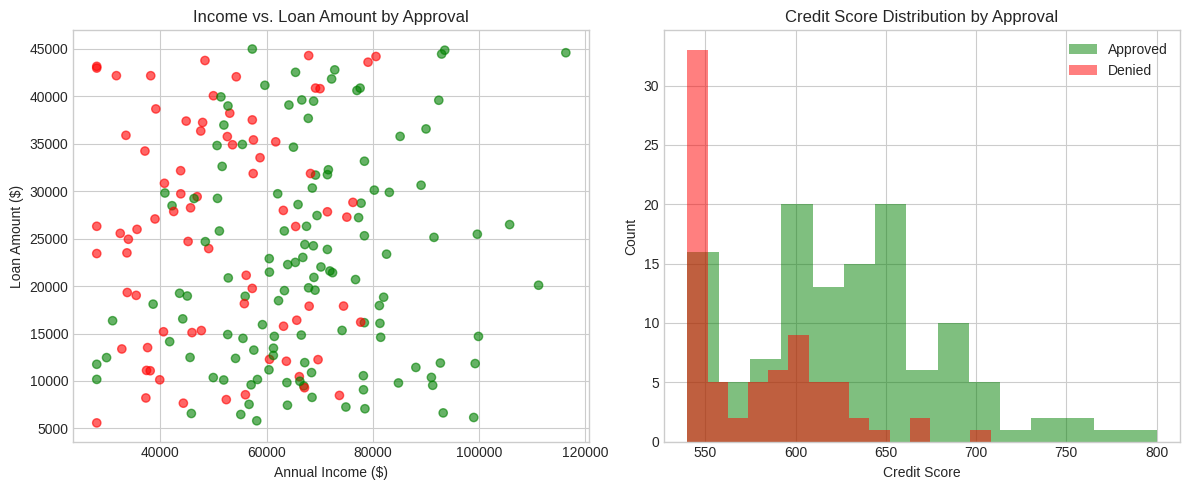

👀 What patterns do you notice in these charts?


In [30]:
# Step 4: Visualize relationships (Chapter 5 skills in action!)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Income vs. Loan Amount, colored by approval
colors = loans['approved'].map({1: 'green', 0: 'red'})
axes[0].scatter(loans['income'], loans['loan_amount'],
                c=colors, alpha=0.6)
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Loan Amount ($)')
axes[0].set_title('Income vs. Loan Amount by Approval')

# Plot 2: Credit score distribution by approval status
loans[loans['approved'] == 1]['credit_score'].hist(
    ax=axes[1], alpha=0.5, label='Approved', color='green', bins=15)
loans[loans['approved'] == 0]['credit_score'].hist(
    ax=axes[1], alpha=0.5, label='Denied', color='red', bins=15)
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Credit Score Distribution by Approval')
axes[1].legend()

plt.tight_layout()
plt.show()

print("👀 What patterns do you notice in these charts?")

In [31]:
# Step 5: Define features and label
# We use income, credit_score, loan_amount, and employment_years
# Note: We're NOT using zip_code as a feature — we'll discuss why shortly
features = ['income', 'credit_score', 'loan_amount', 'employment_years']
X = loans[features]
y = loans['approved']

# Step 6: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {len(X_train)} applications")
print(f"Testing set:  {len(X_test)} applications")

# Step 7: Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Evaluate
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\n📊 Training R² Score: {train_score:.3f}")
print(f"📊 Testing R² Score:  {test_score:.3f}")

# Step 9: Which features drive the prediction?
print("\nFeature Importance (coefficients):")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.6f}")

Training set: 160 applications
Testing set:  40 applications

📊 Training R² Score: 0.263
📊 Testing R² Score:  0.255

Feature Importance (coefficients):
  income: 0.000005
  credit_score: 0.003132
  loan_amount: -0.000007
  employment_years: 0.007802


In [32]:
# Step 10: Make predictions for specific applicants
applicant_1 = pd.DataFrame({
    'income': [55000],
    'credit_score': [680],
    'loan_amount': [15000],
    'employment_years': [3]
})

applicant_2 = pd.DataFrame({
    'income': [30000],
    'credit_score': [580],
    'loan_amount': [40000],
    'employment_years': [1]
})

pred_1 = model.predict(applicant_1)[0]
pred_2 = model.predict(applicant_2)[0]

print("Applicant 1: income=$55k, credit=680, loan=$15k, 3yr employed")
print(f"  Prediction: {pred_1:.3f} → {'Likely approved ✅' if pred_1 > 0.5 else 'Likely denied ❌'}")

print("\nApplicant 2: income=$30k, credit=580, loan=$40k, 1yr employed")
print(f"  Prediction: {pred_2:.3f} → {'Likely approved ✅' if pred_2 > 0.5 else 'Likely denied ❌'}")

print("\n💡 Remember: We're using linear regression for a yes/no problem here.")
print("   In Chapter 7, you'll learn classification algorithms designed for this.")

Applicant 1: income=$55k, credit=680, loan=$15k, 3yr employed
  Prediction: 0.878 → Likely approved ✅

Applicant 2: income=$30k, credit=580, loan=$40k, 1yr employed
  Prediction: 0.263 → Likely denied ❌

💡 Remember: We're using linear regression for a yes/no problem here.
   In Chapter 7, you'll learn classification algorithms designed for this.


### ✏️ Your Turn 3

This is the big one — explore the model and the data:

1. **Visualize the pattern**: Create a scatter plot of `income` vs. `loan_amount` colored by `approved`. Can you see the boundary the model learned?
2. **Test your own applicant**: Create a DataFrame for someone you know (use realistic numbers) and predict their approval.
3. **The fairness question**: Group the original data by `zip_code` and calculate the approval rate for each zip code. Are they the same? What might explain the differences?

In [33]:
# YOUR TURN: Experiment with Example 3
# Try the modifications described above



---

## Case Study: Predicting No-Shows at a Little Havana Clinic 🏥

Let's apply the ML workflow to a new scenario together.

**The problem:** A community health clinic in Little Havana has a 30% no-show rate for appointments. Every empty slot means a wasted hour of staff time and a patient who could have been seen. The clinic director wants to predict which patients will miss their appointments so staff can send targeted reminders.

**The data:** The clinic has historical records with these columns:

| Column | Description |
|--------|-------------|
| patient_age | Patient's age |
| neighborhood | Patient's neighborhood |
| insurance_type | Medicaid, private, uninsured |
| days_since_booking | Days between booking and appointment |
| previous_no_shows | Past missed appointments |
| day_of_week | Day of the appointment |
| showed_up | Whether the patient came (yes/no) |

**Let's work through this together. Fill in the blanks as we go.**

In [34]:
# CASE STUDY: Predicting No-Shows

# Step 1: What type of ML is this?
# Think: Do we have labeled data? What are we predicting?

ml_type = "___________"  # Fill in: "supervised", "unsupervised", or "reinforcement"

print(f"This is a {ml_type} learning problem because:")
print("  - We have historical data with known outcomes (showed_up)")
print("  - We want to predict that outcome for future appointments")

This is a ___________ learning problem because:
  - We have historical data with known outcomes (showed_up)
  - We want to predict that outcome for future appointments


In [35]:
# Step 2: Identify features and label

label = "___________"  # Fill in: which column are we predicting?

# Which columns are potential features?
# List at least 3 numeric features that could help predict no-shows:
numeric_features = [
    "___________",   # Feature 1
    "___________",   # Feature 2
    "___________",   # Feature 3
]

print(f"Label: {label}")
print(f"Features: {numeric_features}")
print(f"\nFrame it: 'Given {numeric_features}, predict {label}'")

Label: ___________
Features: ['___________', '___________', '___________']

Frame it: 'Given ['___________', '___________', '___________'], predict ___________'


### The Ethical Pause ⚖️

Before building this model, we need to ask some hard questions:

**Consider:** The `neighborhood` column is in the data. Should we use it as a feature?

- If patients from certain neighborhoods no-show more often, the model might learn to deprioritize them
- But *why* might those patients miss appointments? Maybe public transportation is unreliable. Maybe they work multiple jobs with inflexible hours.
- The model sees *correlation*, not *causation*

**Discuss with your neighbor or think about this:**

> If the model learns that Medicaid patients no-show more frequently, and the clinic reduces appointment slots for Medicaid patients — is that fair? What alternative approaches could improve attendance without penalizing vulnerable populations?

This is why ML isn't just a technical exercise. The decisions you make about features, data, and how to act on predictions have real consequences for real people.

---

## 🎯 What You Built Today

Congratulations — you just completed your first machine learning project! Here's what you accomplished:

| Example | What You Did | Key Concept |
|---------|-------------|-------------|
| Example 1 | Predicted ice cream sales from temperature | Features → Model → Prediction |
| Example 2 | Trained and evaluated a cafecito sales model | Train/Test Split, R² Score |
| Example 3 | Built a full loan approval predictor | Complete ML Pipeline |
| Case Study | Applied the workflow to a health clinic scenario | Feature Selection + Ethics |

### Key Takeaways
- **ML learns from data** — you provide examples, the algorithm finds patterns
- **Always split your data** — train on 80%, test on 20%, compare the scores
- **Coefficients tell a story** — they reveal which features drive predictions
- **Accuracy isn't everything** — always ask "accurate for *who*?"

### Coming Up Next
In **Chapter 7**, you'll trade regression for **classification** — sorting data into categories (approved/denied, spam/not spam). You'll use **k-Nearest Neighbors** and **Decision Trees** on this same loan dataset. Same data, new algorithms, new insights.

---
*Save this notebook — you'll reference it throughout the ML chapters!*